In [89]:
import pandas as pd

# Read the CSV directly
csv_path = r"cb_indresp_w.csv"
df = pd.read_csv(csv_path)



In [90]:
from pathlib import Path
import pandas as pd

CSV_PATH = Path('cb_indresp_w.csv').resolve()
FILTERED_PATH = CSV_PATH.with_stem(CSV_PATH.stem + '_filtered')

RAW_COLUMNS = [
    'pidp',
    'cb_age',
    'cb_sex',
    'cb_hours',
    'cb_wah',
    'cb_scghq2_dv',
    'cb_betaindin_xw',
    'cb_betaindin_lw',
]

COLUMN_RENAME_MAP = {
    'pidp': 'participant_id',
    'cb_age': 'age_years',
    'cb_sex': 'gender',
    'cb_hours': 'weekly_hours_worked',
    'cb_wah': 'work_from_home_frequency',
    'cb_scghq2_dv': 'stress_score_ghq12',
    'cb_betaindin_xw': 'survey_weight_cross_sectional',
    'cb_betaindin_lw': 'survey_weight_longitudinal',
}

WFH_LABELS = {1.0: 'Always', 2.0: 'Often', 3.0: 'Sometimes', 4.0: 'Never'}
SEX_LABELS = {1.0: 'Male', 2.0: 'Female'}
NEGATIVE_MISSING_CODES = {-9.0, -8.0, -7.0, -3.0, -2.0, -1.0}

if not CSV_PATH.exists():
    raise FileNotFoundError(f"Expected CSV at {CSV_PATH}, but it was not found.")

raw_df = pd.read_csv(CSV_PATH, usecols=RAW_COLUMNS)

for column in ['cb_age', 'cb_hours', 'cb_scghq2_dv']:
    raw_df[column] = pd.to_numeric(raw_df[column], errors='coerce')
    raw_df.loc[raw_df[column].isin(NEGATIVE_MISSING_CODES), column] = pd.NA

raw_df.loc[raw_df['cb_wah'].isin(NEGATIVE_MISSING_CODES), 'cb_wah'] = pd.NA
raw_df.loc[raw_df['cb_sex'].isin(NEGATIVE_MISSING_CODES), 'cb_sex'] = pd.NA

raw_df['cb_wah'] = raw_df['cb_wah'].map(WFH_LABELS)
raw_df['cb_sex'] = raw_df['cb_sex'].map(SEX_LABELS)

analysis_df = raw_df.rename(columns=COLUMN_RENAME_MAP)
analysis_df['stress_case_flag'] = analysis_df['stress_score_ghq12'].ge(4).astype('Int64')
analysis_df['work_from_home_frequency'] = analysis_df['work_from_home_frequency'].astype('category')
analysis_df['gender'] = analysis_df['gender'].astype('category')

analysis_df.to_csv(FILTERED_PATH, index=False)

display(analysis_df.head())
analysis_df.info()
print(f"Saved filtered dataset to {FILTERED_PATH}")


,participant_id,age_years,gender,weekly_hours_worked,work_from_home_frequency,stress_score_ghq12,survey_weight_cross_sectional,survey_weight_longitudinal,stress_case_flag
0,76165.0,37.0,Female,31.0,Always,2.0,0.440938,0.409149,0
1,280165.0,40.0,Female,0.0,Never,0.0,0.755021,0.792630,0
2,599765.0,33.0,Female,37.5,Always,0.0,0.482109,0.414215,0
3,732365.0,34.0,Male,NaN,NaN,12.0,3.836687,1.126293,1
4,1587125.0,54.0,Female,37.0,Often,0.0,0.137141,0.133898,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14811 entries, 0 to 14810
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   participant_id                 14811 non-null  float64 
 1   age_years                      14811 non-null  float64 
 2   gender                         14811 non-null  category
 3   weekly_hours_worked            8764 non-null   float64 
 4   work_from_home_frequency       8771 non-null   category
 5   stress_score_ghq12             14442 non-null  float64 
 6   survey_weight_cross_sectional  14811 non-null  float64 
 7   survey_weight_longitudinal     14811 non-null  float64 
 8   stress_case_flag               14811 non-null  Int64   
dtypes: Int64(1), category(2), float64(6)
memory usage: 853.8 KB
Saved filtered dataset to C:\Users\nhu92\Desktop\DATA1002 ASSIGNMENT\cb_indresp_w_filtered.csv


In [91]:
import pandas as pd

df = pd.read_csv("cb_indresp_w_filtered.csv")  # first row is treated as header
print(len(df))        # total number of data rows (excluding header)
# or
print(df.shape[0])    # also gives total number of data rows

# Detect blank/missing cells
blank_cells = df.isnull()  # Returns True for NaN cells

# Count total number of records (rows) that contain at least one blank cell
rows_with_blank = df.isnull().any(axis=1).sum()

print(f"Number of rows with at least one blank cell: {rows_with_blank}")



14811
14811
Number of rows with at least one blank cell: 6187


In [92]:
import pandas as pd

# 1. Load the dataset
df = pd.read_csv("cb_indresp_w_filtered.csv")
print(f"Original number of rows: {len(df)}")

# 2. Remove rows with any blank/missing cells
df = df.dropna()
print(f"Number of rows after removing blanks: {len(df)}")

# 3. Check for remaining missing values
print("Missing values per column:")
print(df.isnull().sum())

# 4. Fix formatting issues (strip whitespace from string columns)
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.strip()

# 5. Remove duplicate rows
df = df.drop_duplicates()
print(f"Number of rows after removing duplicates: {len(df)}")

# 6. Check for duplicate participant_id
if 'participant_id' in df.columns:
    duplicates = df[df.duplicated(subset='participant_id', keep=False)]
    if not duplicates.empty:
        print(f"Found duplicate participant_id rows:\n{duplicates}")
        df = df.drop_duplicates(subset='participant_id', keep='first')
        print(f"Number of rows after removing participant_id duplicates: {len(df)}")

# 7. Keep only valid ages (14–70 inclusive)
if 'age_years' in df.columns:
    df = df[pd.to_numeric(df['age_years'], errors='coerce').between(14, 70)]
    print(f"Number of rows after keeping only ages 14–70: {len(df)}")

# 8. Check for inconsistent values in specific columns

# stress_score_ghq12 should be 0-12
if 'stress_score_ghq12' in df.columns:
    df = df[df['stress_score_ghq12'].between(0, 12)]
    print("Checked 'stress_score_ghq12': only values 0-12 remain.")

# work_from_home_frequency should be one of the expected categories
valid_wfh = ["Always", "Often", "Sometimes", "Never"]
if 'work_from_home_frequency' in df.columns:
    df = df[df['work_from_home_frequency'].isin(valid_wfh)]
    print("Checked 'work_from_home_frequency': only valid categories remain.")

# stress_case_flag should be 0 or 1
if 'stress_case_flag' in df.columns:
    df = df[df['stress_case_flag'].isin([0, 1, '0', '1'])]
    print("Checked 'stress_case_flag': only 0 or 1 values remain.")

# Remove rows where weekly_hours_worked is between 38 and 70 (inclusive)
if 'weekly_hours_worked' in df.columns:
    df['weekly_hours_worked'] = pd.to_numeric(df['weekly_hours_worked'], errors='coerce')
    df = df.dropna(subset=['weekly_hours_worked'])
    df = df[~df['weekly_hours_worked'].between(38, 70)]
    print(f"Number of rows after removing 38–70 hours/week: {len(df)}")

# 9. Fill remaining missing values with default values
for col in df.select_dtypes(include=['number']).columns:
    df[col] = df[col].fillna(0)

for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna('Unknown')

# 10. Save cleaned dataset
df.to_csv("cb_indresp_w_filtered_cleaned.csv", index=False)
print("Dataset cleaned and saved as cb_indresp_w_filtered_cleaned.csv")


Original number of rows: 14811
Number of rows after removing blanks: 8624
Missing values per column:
participant_id                   0
age_years                        0
gender                           0
weekly_hours_worked              0
work_from_home_frequency         0
stress_score_ghq12               0
survey_weight_cross_sectional    0
survey_weight_longitudinal       0
stress_case_flag                 0
dtype: int64
Number of rows after removing duplicates: 8624
Number of rows after keeping only ages 14–70: 8485
Checked 'stress_score_ghq12': only values 0-12 remain.
Checked 'work_from_home_frequency': only valid categories remain.
Checked 'stress_case_flag': only 0 or 1 values remain.
Number of rows after removing 38–70 hours/week: 6271
Dataset cleaned and saved as cb_indresp_w_filtered_cleaned.csv


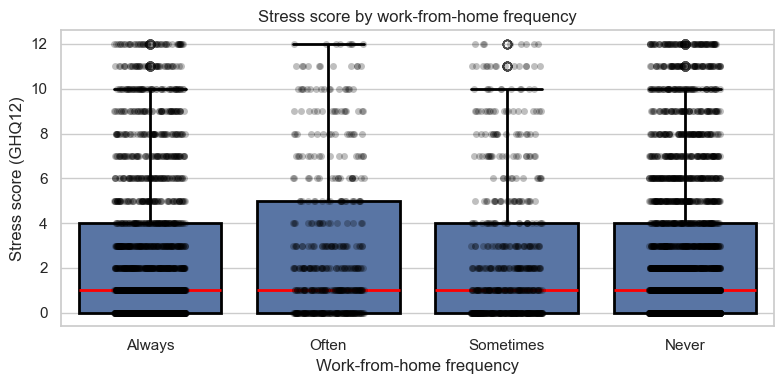

                          count      mean  median   Q1   Q3
work_from_home_frequency                                   
Always                     2073  2.765557     1.0  0.0  4.0
Often                       491  2.865580     1.0  0.0  5.0
Sometimes                   605  2.535537     1.0  0.0  4.0
Never                      3102  2.641199     1.0  0.0  4.0
p-value = 0.2362



C:\Users\nhu92\AppData\Local\Temp\ipykernel_14564\2516773869.py:65: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('work_from_home_frequency')['stress_score_ghq12']


In [94]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd  # make sure pandas is imported

# Create a subset of data dropping rows with missing work_from_home_frequency or stress_score_ghq12
prod_subset_stress = df.dropna(subset=['work_from_home_frequency', 'stress_score_ghq12']).copy()

# Define the correct frequency order
freq_order = ['Always', 'Often', 'Sometimes', 'Never']

# Convert 'work_from_home_frequency' to ordered category
prod_subset_stress['work_from_home_frequency'] = pd.Categorical(
    prod_subset_stress['work_from_home_frequency'],
    categories=freq_order,
    ordered=True
)

sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(8, 4))

# Boxplot with clearer borders
sns.boxplot(
    data=prod_subset_stress,
    x='work_from_home_frequency',
    y='stress_score_ghq12',
    order=freq_order,
    linewidth=2.0,          # thicker borders
    boxprops=dict(edgecolor="black"),   # box border color
    whiskerprops=dict(color="black", linewidth=2),  # whiskers
    capprops=dict(color="black", linewidth=2),      # end caps
    medianprops=dict(color="red", linewidth=2),     # median line
    ax=ax,
)

# Stripplot overlay
sns.stripplot(
    data=prod_subset_stress,
    x='work_from_home_frequency',
    y='stress_score_ghq12',
    order=freq_order,
    color='black',
    alpha=0.25,
    jitter=0.2,
    ax=ax,
)

# Labels
ax.set(
    xlabel='Work-from-home frequency',
    ylabel='Stress score (GHQ12)',
    title='Stress score by work-from-home frequency',
)

plt.tight_layout()
plt.show()


# --- Group statistics ---
# Define the correct frequency order
freq_order = ['Always', 'Often', 'Sometimes', 'Never']

# Group by and calculate descriptive stats
summary_stats = (
    prod_subset_stress
    .groupby('work_from_home_frequency')['stress_score_ghq12']
    .agg([
        ('count', 'count'),
        ('mean', 'mean'),
        ('median', 'median'),
        ('Q1', lambda x: x.quantile(0.25)),
        ('Q3', lambda x: x.quantile(0.75))
    ])
    .reindex(freq_order)  # ensure the logical order
)

print(summary_stats)


# --- ANOVA test ---
groups = [
    df[df["work_from_home_frequency"] == "Always"]["stress_score_ghq12"],
    df[df["work_from_home_frequency"] == "Often"]["stress_score_ghq12"],
    df[df["work_from_home_frequency"] == "Sometimes"]["stress_score_ghq12"],
    df[df["work_from_home_frequency"] == "Never"]["stress_score_ghq12"]
]

f_stat, p_value = stats.f_oneway(*groups)
print(f"p-value = {p_value:.4f}")
print()

